# Etapa 3 | Previsão de Demanda
## N.O.V.A | EDA e Modelagem com Prophet

## Objetivo



Esta etapa analisa e modela a previsão de demanda dos quatro SKUs (Stock Keeping Unit, ou Unidade de Manutenção de Estoque) demonstrativos utilizados pelo Stockly.

O objetivo é avaliar se os padrões temporais presentes no histórico permitem prever a demanda diária dos próximos 365 dias com Prophet. Ao final, será gerado um modelo para cada produto e os quatro serão exportados para integração com o microserviço N.O.V.A.

## Contexto dos dados



Como não foi encontrado um histórico público de vendas por SKU vindo de um ERP de supermercado, será utilizado um dataset sintético com quatro séries de vendas.

Os produtos presentes na fonte são genéricos. Para o protótipo, eles foram associados aos SKUs:
- ***Arroz Agulhinha Tipo 1 Camil 5kg***
- ***Feijão Carioca Tipo 1 Kicaldo 1kg***
- ***Açúcar Refinado Amoroso Caravelas 1kg***
- ***Café Pilão Tradicional 500g***.

Sendo assim, os resultados obtidos aqui dizem respeito ao funcionamento do modelo com esses dados. Quando houver um histórico real do ERP, será necessário, evidentemente, treinar, validar e integrar novamente os modelos com as vendas do supermercado que contratar o serviço.

[Fonte do dataset no Kaggle](https://www.kaggle.com/datasets/ksabishek/product-sales-data)

## Por que o Prophet?


Durante uma pesquisa desk para saber qual modelo melhor se enquadrava no nosso contexto, o Prophet foi escolhido por ser direcionado a problemas de séries temporais de negócio e permitir separar tendência e sazonalidades de forma interpretável (caixa branca).

Isso é pertinente para o Stockly, pois, além de gerar a previsão, o modelo permite analisar quais padrões temporais estão influenciando o resultado. Ademais, feriados e eventos específicos podem ser inseridos posteriormente no treinamento, algo importante quando forem utilizados históricos reais de um ERP, já que promoções e datas comemorativas podem (e devem) alterar diretamente a demanda.

O Prophet também consegue trabalhar com históricos que possuem dias com lacunas, uma característica que é útil para dados de vendas. Por exemplo, se um comércio fechar por alguma emergência, o Prophet consegue trabalhar com essa ausência sem exigir o preenchimento artificial daquele dia.

## Estratégia de um modelo por SKU



Cada produto possui seu próprio histórico de vendas e pode apresentar tendência e sazonalidade diferentes. Como o Prophet trabalha com uma série-alvo por treinamento, será utilizado um modelo independente para cada produto.

Por conta disso, cada produto terá seus padrões aprendidos, avaliados e salvos para integração separadamente.

## Setup

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import re
import unicodedata
from pathlib import Path
from IPython.display import display
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet
from prophet.diagnostics import cross_validation
from prophet.serialize import model_to_json


plt.rcParams["figure.figsize"] = (12, 5)

## Carregamento e estrutura dos dados



A primeira verificação será feita sobre a estrutura do dataset, observando quantidade de registros, tipos das colunas, valores ausentes e duplicatas.

In [54]:
mapa_produtos = {
    "Q-P1": "Arroz Agulhinha Tipo 1 Camil 5kg",
    "Q-P2": "Feijão Carioca Tipo 1 Kicaldo 1kg",
    "Q-P3": "Açúcar Refinado Amoroso Caravelas 1kg",
    "Q-P4": "Café Pilão Tradicional 500g"
}

produtos = list(mapa_produtos.values())

dados_brutos = pd.read_csv(Path("../dataset/data_prev.csv"))
dados_brutos = dados_brutos.drop(columns=["Unnamed: 0"], errors="ignore")
dados_brutos.head(1)


,Date,Q-P1,Q-P2,Q-P3,Q-P4,S-P1,S-P2,S-P3,S-P4
0,13-06-2010,5422,3725,576,907,17187.74,23616.5,3121.92,6466.91


Como se pode observar, constam os nomes genéricos do dataset. Para fins de informação:

Q-P1: Total de unidades vendidas do produto 1

Q-P2: Total de unidades vendidas do produto 2

Q-P3: Total de unidades vendidas do produto 3

Q-P4: Total de unidades vendidas do produto 4

S-P1: Receita total do produto 1

S-P2: Receita total do produto 2

S-P3: Receita total do produto 3

S-P4: Receita total do produto 4

In [55]:
dados_brutos = dados_brutos.rename(columns=mapa_produtos)
dados_brutos.head(5)

,Date,Arroz Agulhinha Tipo 1 Camil 5kg,Feijão Carioca Tipo 1 Kicaldo 1kg,Açúcar Refinado Amoroso Caravelas 1kg,Café Pilão Tradicional 500g,S-P1,S-P2,S-P3,S-P4
0,13-06-2010,5422,3725,576,907,17187.74,23616.50,3121.92,6466.91
1,14-06-2010,7047,779,3578,1574,22338.99,4938.86,19392.76,11222.62
2,15-06-2010,1572,2082,595,1145,4983.24,13199.88,3224.90,8163.85
3,16-06-2010,5657,2399,3140,1672,17932.69,15209.66,17018.80,11921.36
4,17-06-2010,3668,3207,2184,708,11627.56,20332.38,11837.28,5048.04


Para uma melhor imersão no protótipo, foi efetuada a mudança de nomes dos produtos para itens comuns em supermercado.

In [56]:

resumo_estrutura = pd.DataFrame({
    "Registros": [len(dados_brutos)],
    "Colunas": [dados_brutos.shape[1]],
    "Colunas numéricas": [dados_brutos.select_dtypes(include="number").shape[1]],
    "Valores ausentes": [dados_brutos.isna().sum().sum()],
    "Duplicatas exatas": [dados_brutos.duplicated().sum()]
})

display(resumo_estrutura)

,Registros,Colunas,Colunas numéricas,Valores ausentes,Duplicatas exatas
0,4600,9,8,0,0


Não foram encontrados valores ausentes ou duplicatas, portanto a estrutura geral da base não exige correções nessa questão.

Uma observação importante é que a previsão será feita sobre quantidade vendida. Logo, as quatro colunas de receita não entram na modelagem. Em relação à coluna Date, ela precisa ser validada, pois qualquer problema nela interfere diretamente na ordem da série temporal.

## Integridade das datas

Como a previsão depende da ordem no tempo, a coluna Date será convertida para o formato de data. Os valores que não puderem ser interpretados serão exibidos para identificar o motivo da falha.

In [57]:
datas_convertidas = pd.to_datetime(
    dados_brutos["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

datas_invalidas = dados_brutos.loc[
    datas_convertidas.isna(),
    ["Date", *produtos]].copy()

print(f"Datas válidas: {datas_convertidas.notna().sum()}")
print(f"Datas não válidas: {datas_convertidas.isna().sum()}")

display(datas_invalidas)

Datas válidas: 4574
Datas não válidas: 26


,Date,Arroz Agulhinha Tipo 1 Camil 5kg,Feijão Carioca Tipo 1 Kicaldo 1kg,Açúcar Refinado Amoroso Caravelas 1kg,Café Pilão Tradicional 500g
109,31-09-2010,4986,342,4978,558
170,31-11-2010,4632,3930,523,1581
473,31-09-2011,2242,401,5926,789
534,31-11-2011,325,3476,4588,1771
836,31-09-2012,1003,256,1346,1449
897,31-11-2012,2509,2666,4146,593
1200,31-09-2013,597,709,5470,1994
1261,31-11-2013,7681,1235,347,1087
1564,31-09-2014,5333,833,3494,618
1625,31-11-2014,3870,2779,3246,1290


Foram encontradas 26 linhas com datas inválidas, repetidas em diferentes anos. Como elas não existem no calendário, qualquer ajuste significaria criar uma informação não existente. Além disso, um resampling não resolveria esse problema, pois depende de datas válidas e não permite determinar a data correta dessas observações.    

Sendo assim, esses dados serão removidos. Porém, isso ainda não garante que o calendário esteja completo, por isso, também é necessário verificar se existem outros dias ausentes no histórico.

## Período histórico e lacunas no calendário



Depois de definir as datas válidas, será verificado quanto tempo o histórico cobre e quais dias não possuem observações. Isso é importante para entender quantos ciclos anuais estão disponíveis e como as lacunas se distribuem ao longo da série.

In [58]:
dados_validos = dados_brutos.copy()
dados_validos["ds"] = datas_convertidas

dados_validos = (
    dados_validos
    .dropna(subset=["ds"])
    .sort_values("ds")
    .reset_index(drop=True)
)

datas_esperadas = pd.date_range(
    dados_validos["ds"].min(),
    dados_validos["ds"].max(),
    freq="D"
)

datas_ausentes = datas_esperadas.difference(dados_validos["ds"])

resumo_periodo = pd.DataFrame({
    "Início": [dados_validos["ds"].min().date()],
    "Fim": [dados_validos["ds"].max().date()],
    "Registros válidos": [len(dados_validos)],
    "Datas duplicadas": [dados_validos["ds"].duplicated().sum()],
    "Dias ausentes": [len(datas_ausentes)]
})

display(resumo_periodo)

,Início,Fim,Registros válidos,Datas duplicadas,Dias ausentes
0,2010-06-13,2023-02-03,4574,0,45


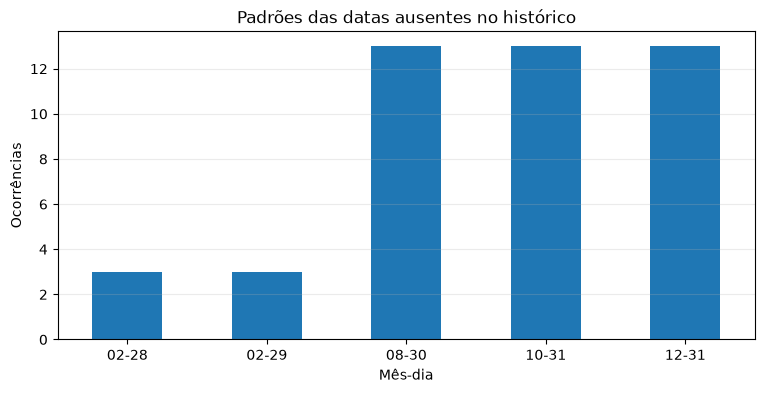

In [59]:
padroes_lacunas = (
    pd.Series(datas_ausentes.strftime("%m-%d"), name="Mês-dia")
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 4))
padroes_lacunas.plot(kind="bar")
plt.title("Padrões das datas ausentes no histórico")
plt.xlabel("Mês-dia")
plt.ylabel("Ocorrências")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.show()

Após retirar as datas inválidas, os registros ficam entre junho de 2010 e fevereiro de 2023. Esse período cobre mais de doze anos, fornecendo vários ciclos completos para analisar os padrões sazonais.

Além do mais, sobre os dias ausentes, é informado na fonte do dataset que as lojas permanecem fechadas no dia 31 de dezembro, razão pela qual existe essa lacuna. Nos demais casos não existe uma justificativa documentada, logo, não há informação suficiente para estimar as vendas que faltam.

Como o Prophet consegue trabalhar com lacunas, essas datas ausentes serão mantidas sem qualquer preenchimento.

## Preparação das séries



Para os quatro produtos, será aplicada uma divisão por 8. Essa é uma decisão de simulação do protótipo para representar um volume de vendas mais compatível com um supermercado de médio-grande porte, que é onde será o foco do produto.

É importante notar que, como a transformação será aplicada igualmente a toda a série, os padrões sazonais permanecem os mesmos.

In [60]:
dados = dados_validos[["ds", *produtos]].copy()

for produto in produtos:
    dados[produto] = dados[produto] / 8

resumo_vendas = (
    dados[produtos].describe()
    .T[["mean", "std", "min", "max"]]
    .rename(columns={
        "mean": "Média",
        "std": "Desvio padrão",
        "min": "Mínimo",
        "max": "Máximo"
    }).round(2)
)

display(resumo_vendas)

,Média,Desvio padrão,Mínimo,Máximo
Arroz Agulhinha Tipo 1 Camil 5kg,515.42,280.46,31.75,999.75
Feijão Carioca Tipo 1 Kicaldo 1kg,266.21,136.19,31.38,499.75
Açúcar Refinado Amoroso Caravelas 1kg,392.97,208.88,31.25,750.00
Café Pilão Tradicional 500g,140.47,62.23,31.25,250.00


## Decomposição temporal



A decomposição será utilizada para separar o comportamento mensal em tendência, sazonalidade anual e resíduos. Isso permite verificar quanto do movimento das séries realmente se repete ao longo do ano e quanto permanece sem ser explicado por esses componentes.

In [61]:
serie_mensal = (
    dados
    .set_index("ds")[produtos]
    .resample("MS")
    .mean()
)

def plotar_decomposicao(produto):
    decomposicao = seasonal_decompose(
        serie_mensal[produto],
        model="additive",
        period=12,
        extrapolate_trend=12
    )

    fig = decomposicao.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle(produto, y=1.02)
    plt.show()

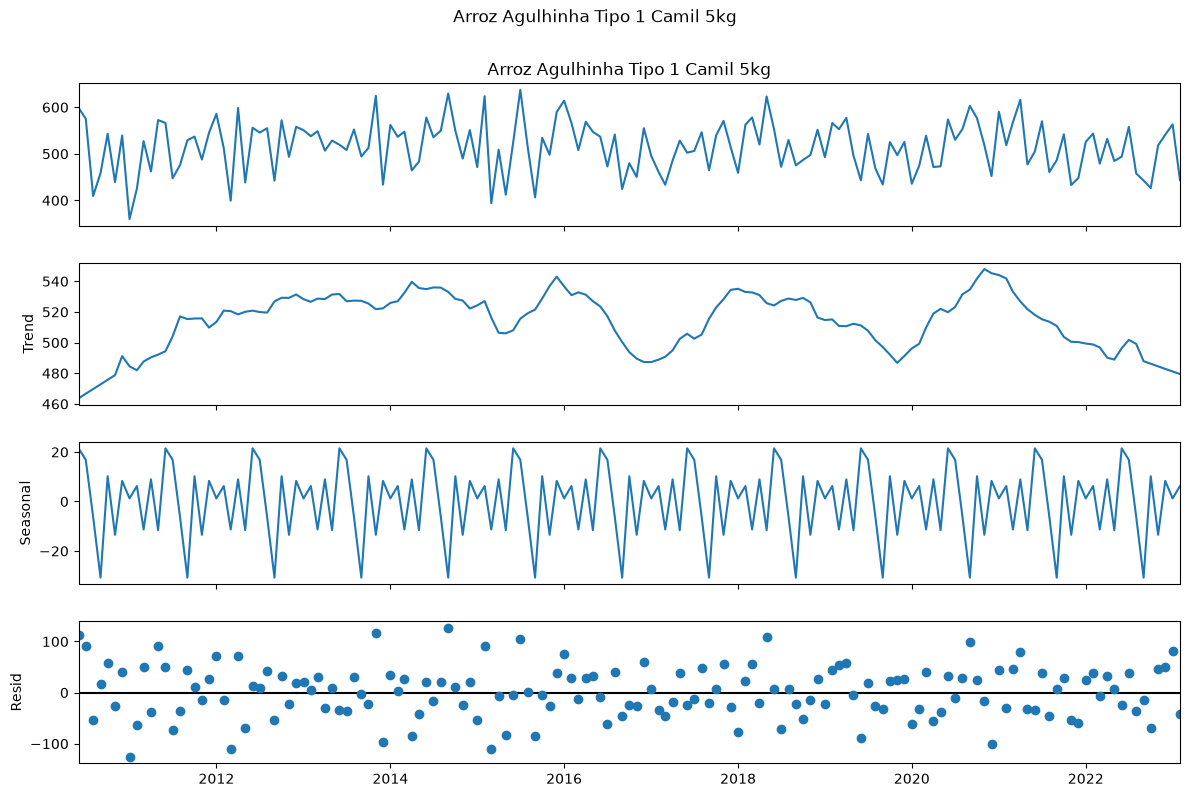

In [62]:
plotar_decomposicao("Arroz Agulhinha Tipo 1 Camil 5kg")

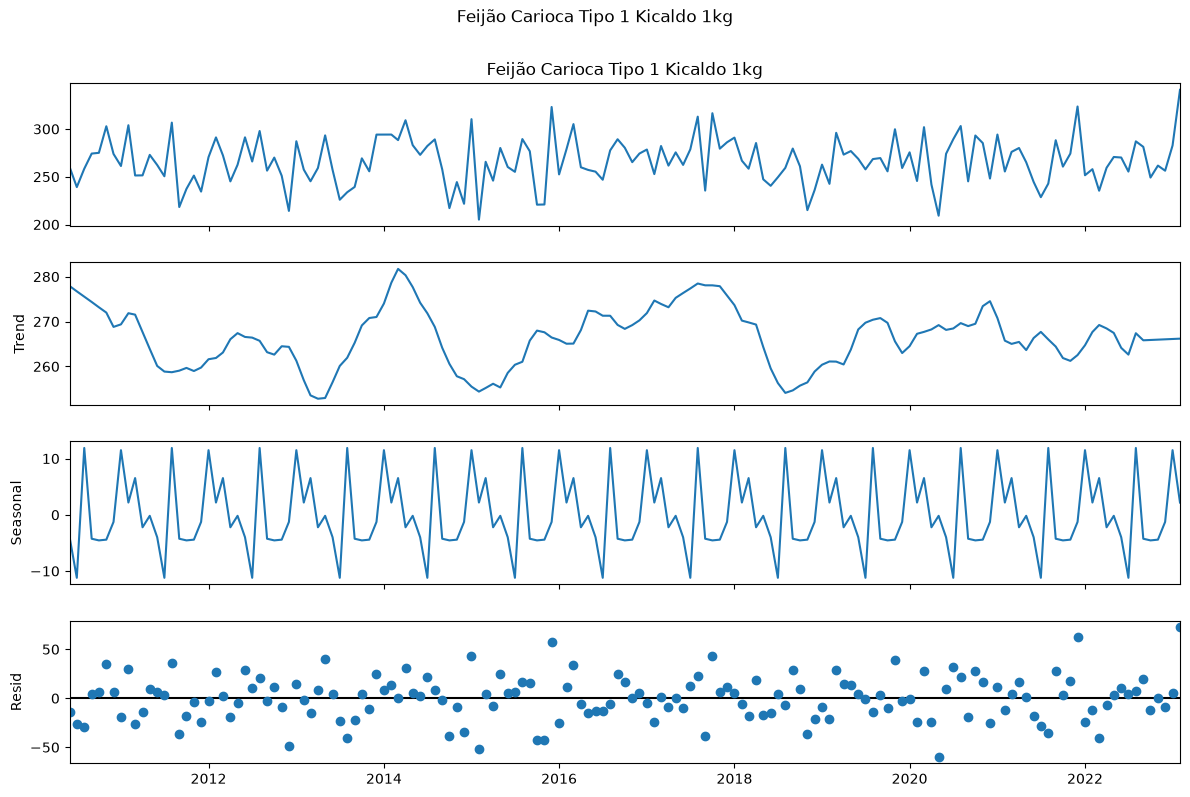

In [63]:
plotar_decomposicao("Feijão Carioca Tipo 1 Kicaldo 1kg")

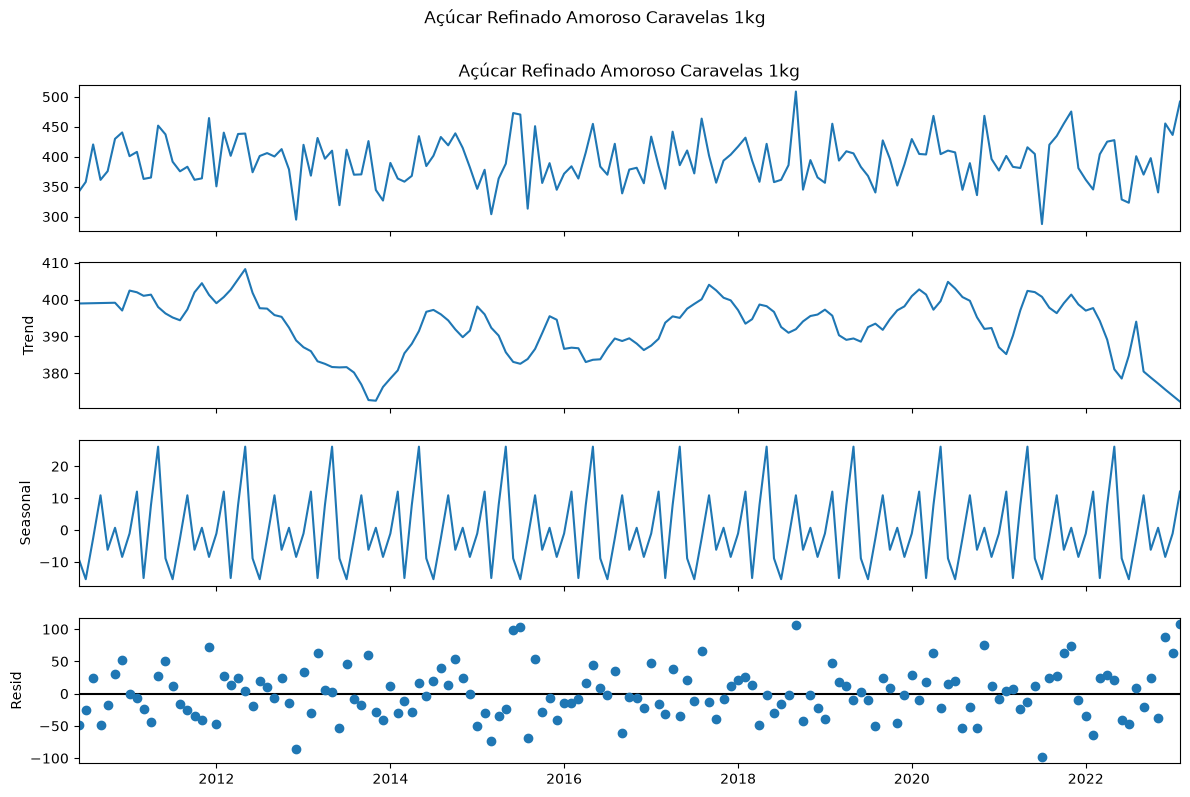

In [64]:
plotar_decomposicao("Açúcar Refinado Amoroso Caravelas 1kg")

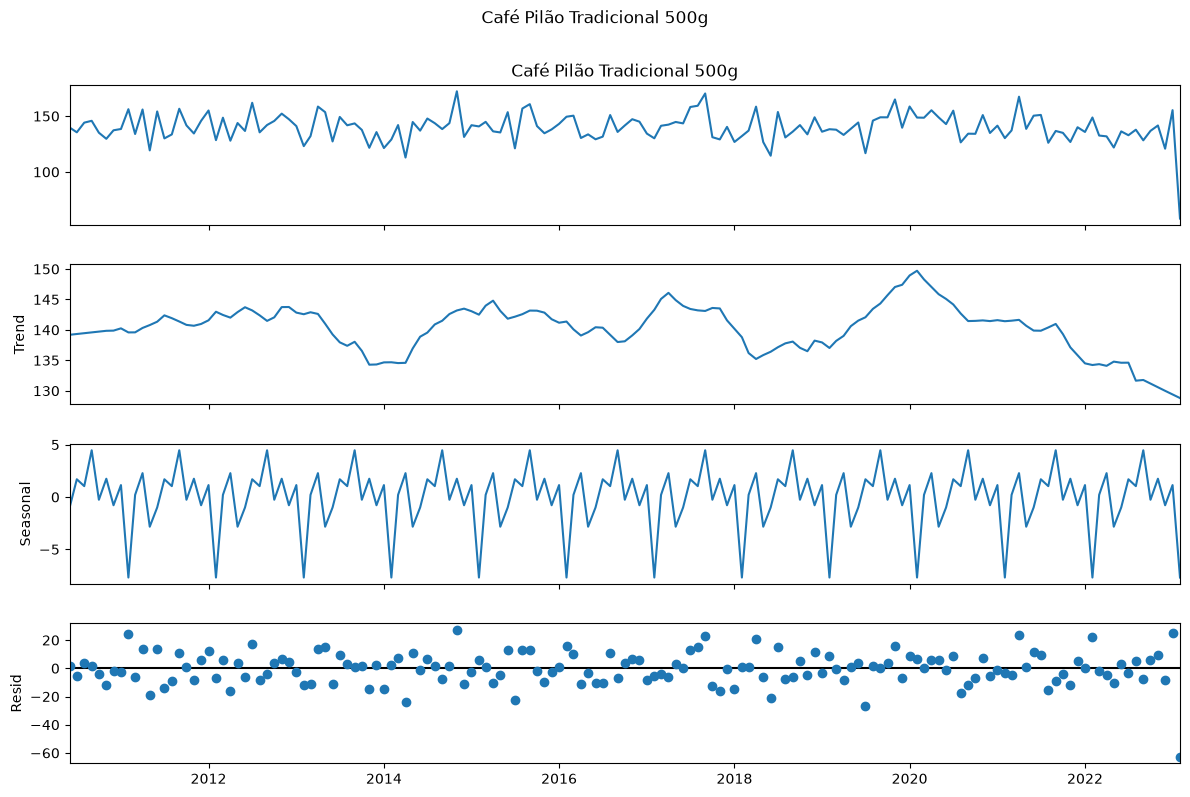

In [65]:
plotar_decomposicao("Café Pilão Tradicional 500g")

A decomposição mostra que os quatro produtos possuem mudanças relevantes de tendência ao longo do tempo e também um padrão sazonal anual, ainda que de baixa amplitude. Porém, algo importante a observar é que os resíduos mostram variações muito altas (em módulo) em Arroz Agulhinha e Açúcar Refinado quando comparado ao componente sazonal, o que significa que a sazonalidade tem um peso não tão significativo nas variações mensais.

No fim, constata-se que a sazonalidade anual é pertinente o suficiente, então será ativada na modelagem. Ademais, é válido notar que a tendência já faz parte da estrutura do Prophet, sem necessidade de ativar.

A validação cruzada será necessária para verificar se o modelo consegue utilizar esses padrões para gerar previsões estáveis.


## Decisões para modelagem



A sazonalidade anual será ativada no Prophet, conforme indicado pela decomposição. Ademais, a tendência já é modelada pelo próprio Prophet.

A sazonalidade semanal não foi analisada previamente nesse colab. Mas como as séries possuem frequência diária, ela também será ativada, para que o Prophet estime um possível padrão presente entre os dias da semana.

Por fim, a validação cruzada utilizará um horizonte de 365 dias, correspondente ao mesmo período de previsão definido para o micro-serviço.

## Setup do Prophet




O intervalo de incerteza gerado pelo Prophet para cada previsão será definido como 80%.


In [66]:
def criar_modelo_prophet():
    return Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        interval_width=0.80
    )

## Validação cruzada temporal



Como o objetivo do serviço é prever os próximos 365 dias, cada janela de validação utilizará esse mesmo horizonte.

Serão utilizados quatro cutoffs em anos diferentes. Em cada um deles, o Prophet será treinado somente com o histórico disponível até aquela data e avaliado durante o ano seguinte. Assim, será possível verificar se o desempenho se repete em diferentes períodos do dataset.

A avaliação utilizará MAE, MAPE e RMSE. Além disso, será medida a cobertura do intervalo de incerteza discutido anteriormente.

In [67]:
HORIZONTE_DIAS = 365
horizonte = pd.Timedelta(days=HORIZONTE_DIAS)

data_min = dados["ds"].min()
data_max = dados["ds"].max()
limite_cutoff = data_max - horizonte

cutoffs_candidatos = []

for ano in sorted(dados["ds"].dt.year.unique()):
    datas_ano = dados.loc[dados["ds"].dt.year == ano, "ds"]

    if datas_ano.empty:
        continue

    cutoff = datas_ano.max()
    historico_disponivel = cutoff - data_min

    if (
        historico_disponivel >= pd.Timedelta(days=3 * 365)
        and cutoff <= limite_cutoff
    ):
        cutoffs_candidatos.append(cutoff)

cutoffs = cutoffs_candidatos[-4:]

resumo_cutoffs = pd.DataFrame({
    "Cutoff": cutoffs,
    "Fim da janela de validação": [c + horizonte for c in cutoffs]
})

display(resumo_cutoffs)

,Cutoff,Fim da janela de validação
0,2018-12-30,2019-12-30
1,2019-12-30,2020-12-29
2,2020-12-30,2021-12-30
3,2021-12-30,2022-12-30


In [68]:
modelos_avaliacao = {}
resultados_cv = {}
metricas_janelas = []

for produto in produtos:
    base_produto = (
        dados[["ds", produto]]
        .rename(columns={produto: "y"})
        .copy()
    )

    modelo = criar_modelo_prophet()
    modelo.fit(base_produto)

    modelos_avaliacao[produto] = modelo

    cv = cross_validation(
        modelo,
        cutoffs=cutoffs,
        horizon=f"{HORIZONTE_DIAS} days",
        disable_tqdm=True
    )

    resultados_cv[produto] = cv

    for cutoff, janela in cv.groupby("cutoff"):
        erro = janela["y"] - janela["yhat"]

        mae = np.abs(erro).mean()
        rmse = np.sqrt(np.mean(erro ** 2))
        mape = (np.abs(erro) / janela["y"]).mean() * 100
        cobertura = (
            (janela["y"] >= janela["yhat_lower"])
            & (janela["y"] <= janela["yhat_upper"])
        ).mean() * 100

        metricas_janelas.append({
            "Produto": produto,
            "Cutoff": cutoff,
            "MAE": mae,
            "MAPE (%)": mape,
            "RMSE": rmse,
            "Cobertura (%)": cobertura
        })

metricas_janelas = pd.DataFrame(metricas_janelas)

resumo_metricas = (
    metricas_janelas.groupby("Produto").agg(
        MAE_medio=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        MAPE_medio=("MAPE (%)", "mean"),
        MAPE_std=("MAPE (%)", "std"),
        RMSE_medio=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        Cobertura_media=("Cobertura (%)", "mean")
    ).round(2)
)

display(resumo_metricas)

05:00:41 - cmdstanpy - INFO - Chain [1] start processing
05:00:41 - cmdstanpy - INFO - Chain [1] done processing
05:00:41 - cmdstanpy - INFO - Chain [1] start processing
05:00:41 - cmdstanpy - INFO - Chain [1] done processing
05:00:42 - cmdstanpy - INFO - Chain [1] start processing
05:00:42 - cmdstanpy - INFO - Chain [1] done processing
05:00:42 - cmdstanpy - INFO - Chain [1] start processing
05:00:42 - cmdstanpy - INFO - Chain [1] done processing
05:00:43 - cmdstanpy - INFO - Chain [1] start processing
05:00:43 - cmdstanpy - INFO - Chain [1] done processing
05:00:43 - cmdstanpy - INFO - Chain [1] start processing
05:00:43 - cmdstanpy - INFO - Chain [1] done processing
05:00:44 - cmdstanpy - INFO - Chain [1] start processing
05:00:44 - cmdstanpy - INFO - Chain [1] done processing
05:00:44 - cmdstanpy - INFO - Chain [1] start processing
05:00:45 - cmdstanpy - INFO - Chain [1] done processing
05:00:45 - cmdstanpy - INFO - Chain [1] start processing
05:00:45 - cmdstanpy - INFO - Chain [1]

,MAE_medio,MAE_std,MAPE_medio,MAPE_std,RMSE_medio,RMSE_std,Cobertura_media
Produto,,,,,,,
Arroz Agulhinha Tipo 1 Camil 5kg,243.38,5.76,116.08,5.39,280.87,5.08,74.69
Açúcar Refinado Amoroso Caravelas 1kg,182.98,7.34,106.28,5.51,210.67,5.82,72.75
Café Pilão Tradicional 500g,53.58,1.06,58.66,5.26,62.16,1.24,74.00
Feijão Carioca Tipo 1 Kicaldo 1kg,120.03,3.42,87.25,6.22,138.19,2.64,71.51


Os baixos desvios padrão mostram que o desempenho mudou pouco entre as quatro janelas da validação cruzada. Logo, as métricas de erro ficam estáveis ao longo dos anos avaliados.

Os maiores erros correspondem a Arroz Agulhinha e Açúcar Refinado, ambos com MAPE acima de 100%, resultado esse que é coerente com suas variações significativas nos resíduos da  decomposição.

Somado a isso, o RMSE fica cerca de 15% acima do MAE nos quatro produtos. Isso não indica necessariamente a presença de outliers, mas mostra que erros de maior magnitude recebem uma penalização maior pelo método da métrica.

Os resultados mostram que o Prophet consegue aprender parte do padrão presente nas séries, mas com erros altos nas previsões diárias. Como o dataset é sintético, esse desempenho é suficiente para demonstrar o funcionamento do microserviço no protótipo.


In [69]:
ultimo_cutoff = cutoffs[-1]

def plotar_validacao(produto):
    janela = resultados_cv[produto]
    janela = janela[janela["cutoff"] == ultimo_cutoff].copy()

    plt.figure(figsize=(13, 5))
    plt.plot(janela["ds"], janela["y"], label="Real")
    plt.plot(janela["ds"], janela["yhat"], label="Previsto")
    plt.fill_between(
        janela["ds"],
        janela["yhat_lower"],
        janela["yhat_upper"],
        alpha=0.20,
        label="Intervalo de incerteza"
    )
    plt.title(f"{produto} | Validação após {ultimo_cutoff.date()}")
    plt.xlabel("Data")
    plt.ylabel("Unidades")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

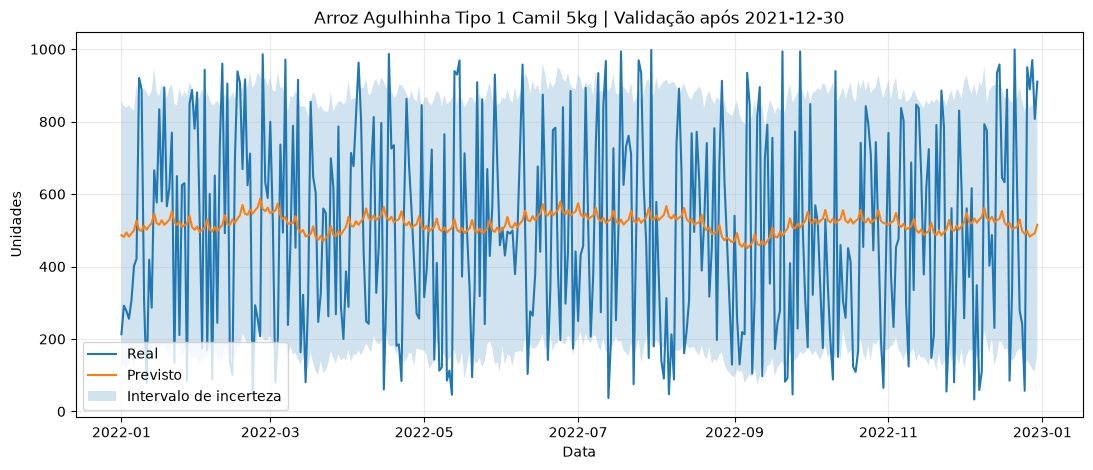

In [70]:
plotar_validacao("Arroz Agulhinha Tipo 1 Camil 5kg")

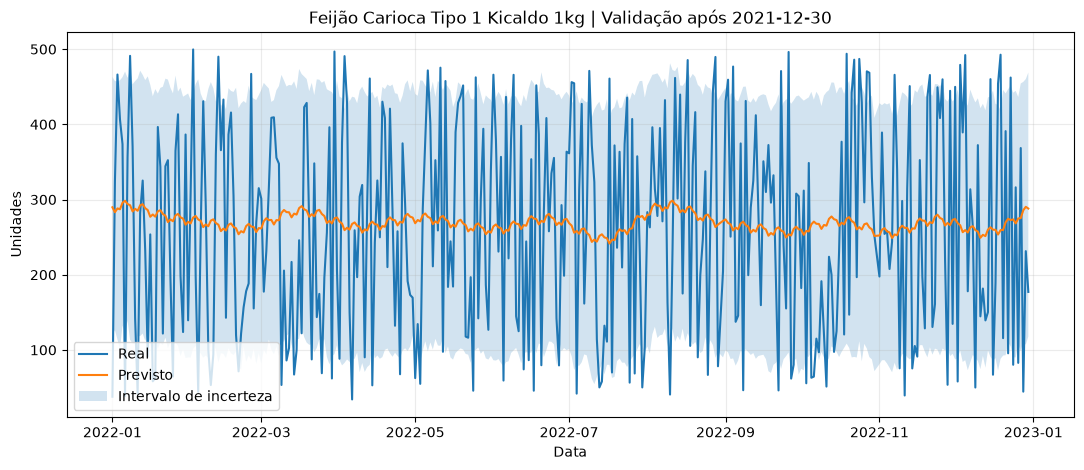

In [71]:
plotar_validacao("Feijão Carioca Tipo 1 Kicaldo 1kg")

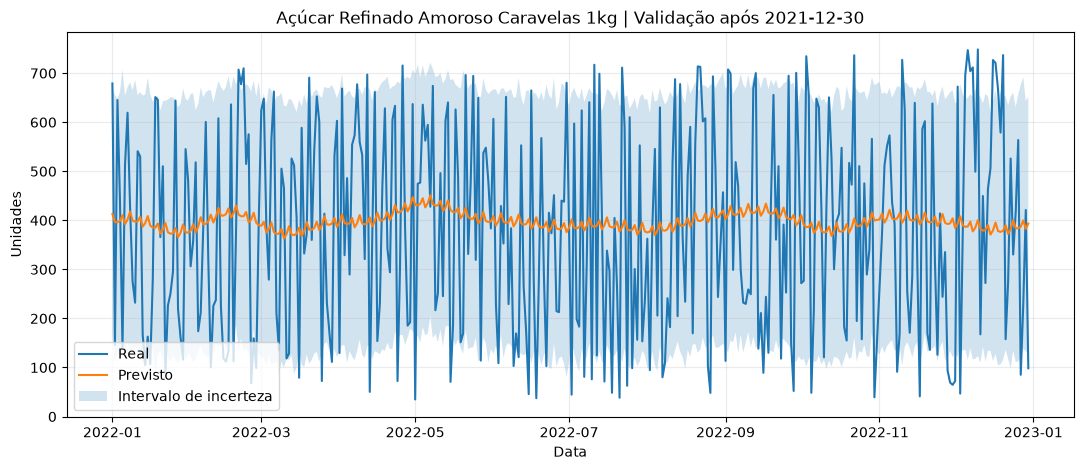

In [72]:
plotar_validacao("Açúcar Refinado Amoroso Caravelas 1kg")

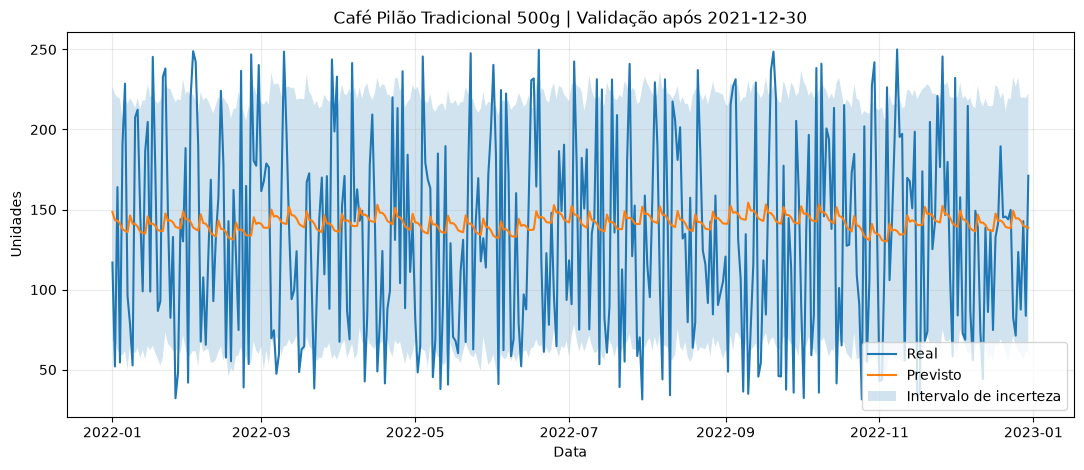

In [73]:
plotar_validacao("Café Pilão Tradicional 500g")

Em um período mais recente, as previsões dos quatro produtos ficam próximas do centro e acompanham apenas movimentos suaves ao longo do ano, muito divergentes das vendas reais, que alternam com alta intensidade entre valores baixos e altos. Isso mostra que o Prophet consegue representar o padrão das séries, mas não acompanha a variação diária em si.

De forma visual, o principal limite não parece ser as subidas ou descidas da previsão, mas a diferença de amplitude entre a curva prevista e as "reais". Esse comportamento explica as métricas anteriores e também a cobertura abaixo de 80%, já que parte dos picos e quedas ultrapassa o intervalo de incerteza.

Mesmo ao ampliar arbitrariamente o intervalo de incerteza, ocorreram ainda alguns picos extremos fora da faixa. Como o dataset é sintético, esse comportamento será tratado como uma limitação dos dados utilizados pra modelagem.

## Componentes aprendidos pelo Prophet



Após a validação, os componentes aprendidos serão analisados para verificar como o Prophet representou a tendência e as sazonalidades semanal e anual de cada produto.

Componentes aprendidos: Arroz Agulhinha Tipo 1 Camil 5kg


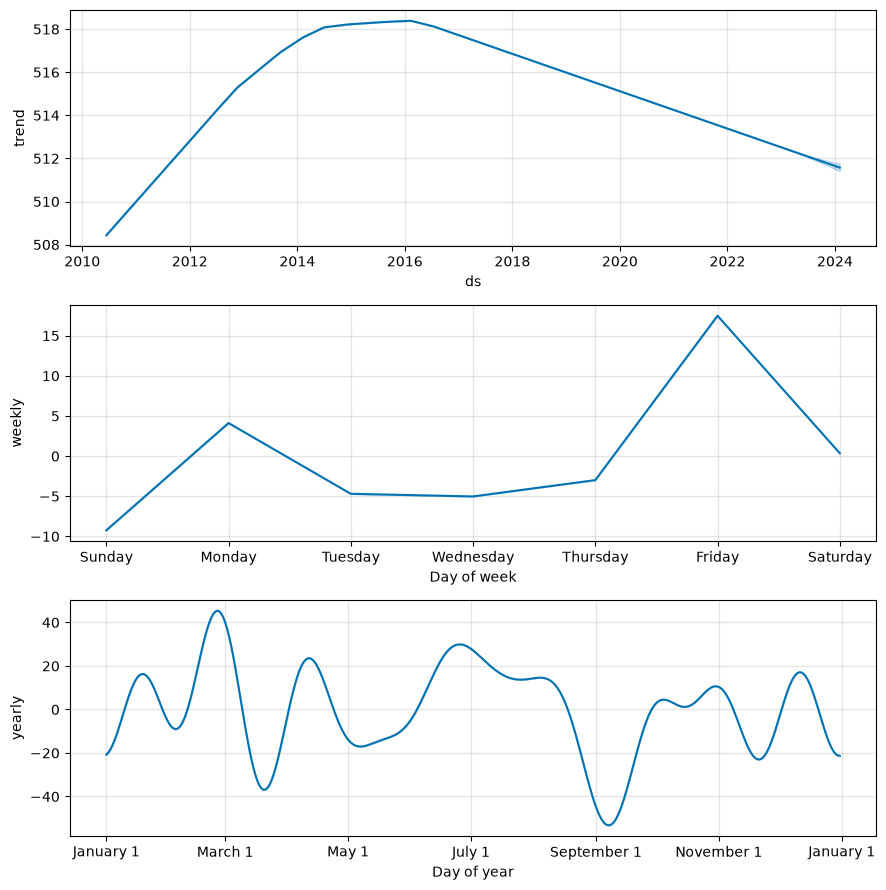

Componentes aprendidos: Feijão Carioca Tipo 1 Kicaldo 1kg


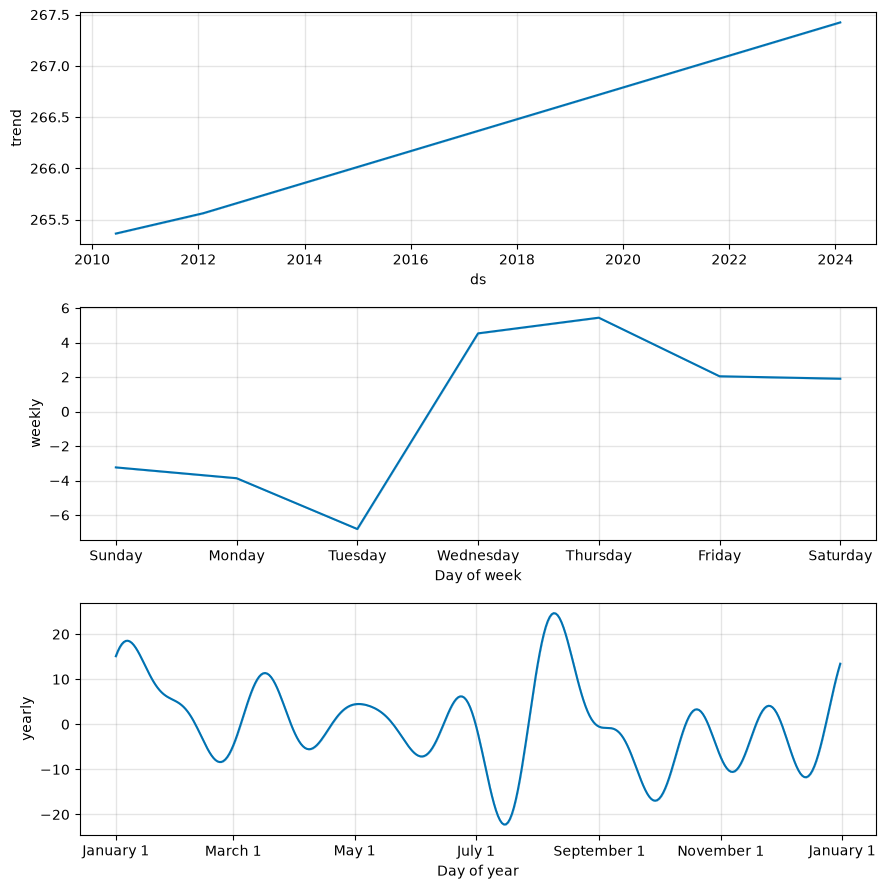

Componentes aprendidos: Açúcar Refinado Amoroso Caravelas 1kg


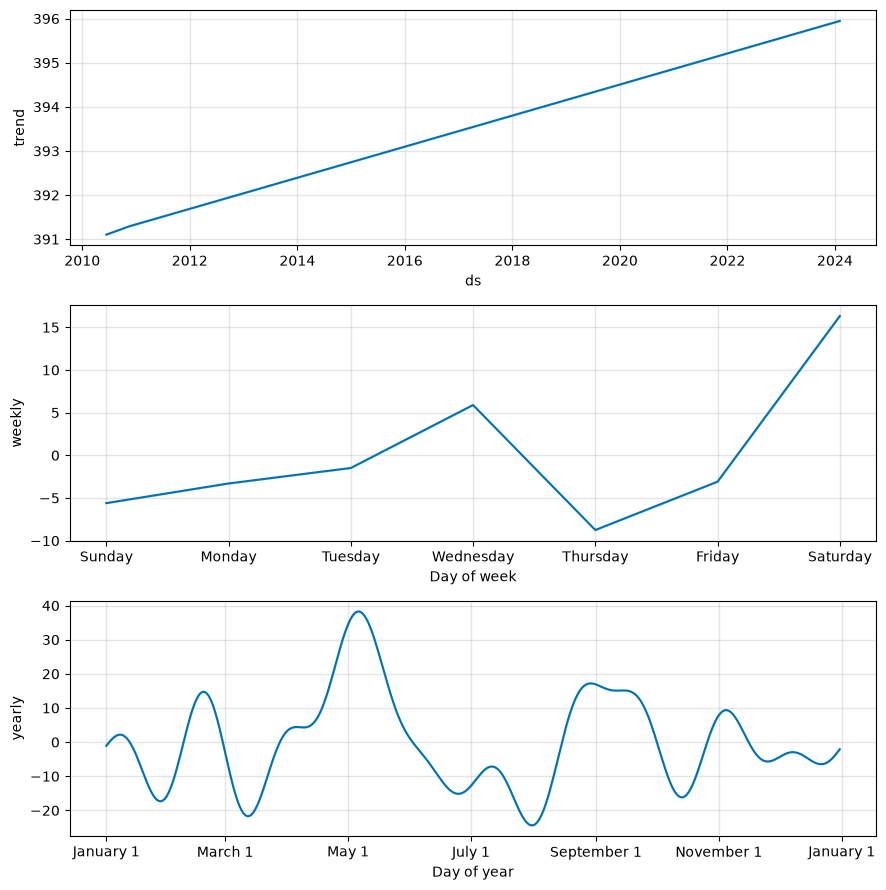

Componentes aprendidos: Café Pilão Tradicional 500g


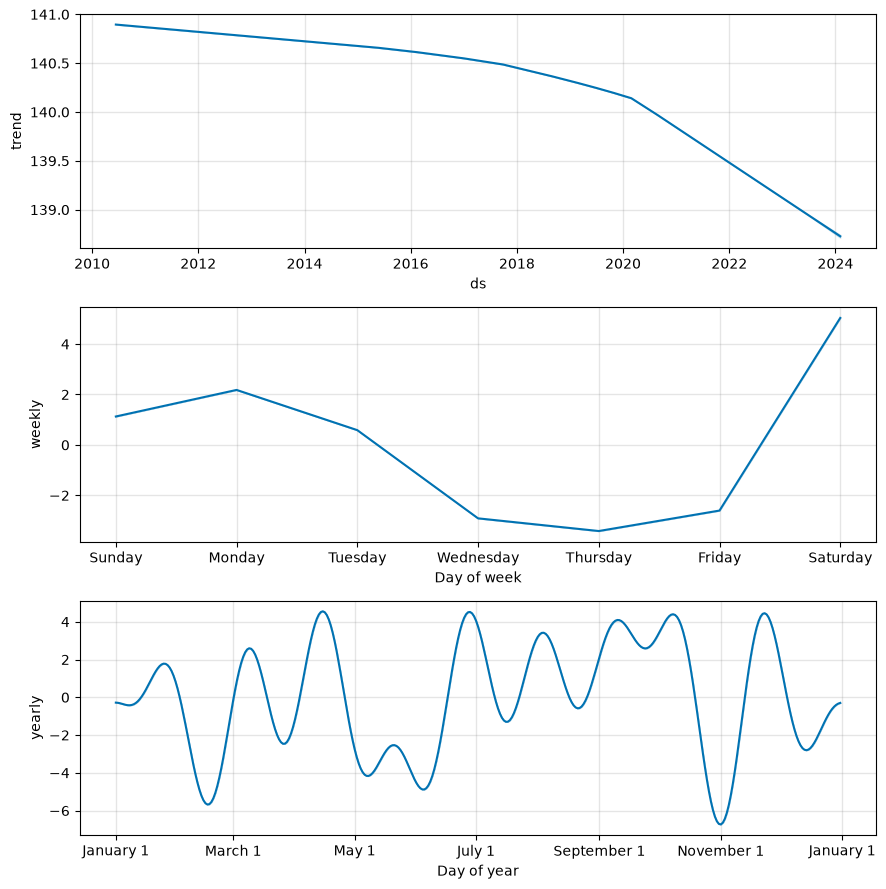

In [74]:
for produto in produtos:
    modelo = modelos_avaliacao[produto]

    futuro = modelo.make_future_dataframe(
        periods=HORIZONTE_DIAS,
        freq="D"
    )

    previsao = modelo.predict(futuro)

    print(f"Componentes aprendidos: {produto}")
    fig = modelo.plot_components(previsao)
    plt.show()

Fica evidente que, em geral, a sazonalidade anual é o componente com maior variação nos quatro modelos.

No entanto, a amplitude desses componentes ainda é muito pequena diante das oscilações observadas nas vendas reais, como visto anteriormente. Isso ajuda a explicar os erros anteriores, pois o modelo consegue representar tendência e sazonalidades das séries, mas grande parte da variação diária em si permanece fora desses padrões.

## Reajuste dos modelos finais



Cada modelo será treinado uma última vez com todo o histórico disponível do seu respectivo produto para gerar os arquivos json que irão para integração com o Stockly.

In [75]:
modelos_finais = {}

for produto in produtos:
    base_produto = (
        dados[["ds", produto]]
        .rename(columns={produto: "y"})
        .copy()
    )

    modelo = criar_modelo_prophet()
    modelo.fit(base_produto)

    modelos_finais[produto] = modelo

    print(f"Modelo final treinado: {produto}")

05:01:01 - cmdstanpy - INFO - Chain [1] start processing
05:01:01 - cmdstanpy - INFO - Chain [1] done processing
05:01:02 - cmdstanpy - INFO - Chain [1] start processing


Modelo final treinado: Arroz Agulhinha Tipo 1 Camil 5kg


05:01:02 - cmdstanpy - INFO - Chain [1] done processing
05:01:02 - cmdstanpy - INFO - Chain [1] start processing


Modelo final treinado: Feijão Carioca Tipo 1 Kicaldo 1kg


05:01:02 - cmdstanpy - INFO - Chain [1] done processing
05:01:03 - cmdstanpy - INFO - Chain [1] start processing


Modelo final treinado: Açúcar Refinado Amoroso Caravelas 1kg


05:01:03 - cmdstanpy - INFO - Chain [1] done processing


Modelo final treinado: Café Pilão Tradicional 500g


## Exportação dos modelos

In [76]:
loja_id = "loja_demo"

pasta_modelos = Path("../../modelo_previsao/modelos") / loja_id
pasta_modelos.mkdir(parents=True, exist_ok=True)


def gerar_nome_arquivo(produto):
    nome = unicodedata.normalize("NFKD", produto)
    nome = nome.encode("ascii", "ignore").decode("ascii")
    nome = re.sub(r"[^a-zA-Z0-9]+", "_", nome)
    nome = nome.strip("_").lower()

    return f"modelo_{nome}.json"


arquivos_modelos = {}

for produto, modelo in modelos_finais.items():
    nome_arquivo = gerar_nome_arquivo(produto)
    caminho = pasta_modelos / nome_arquivo

    caminho.write_text(
        model_to_json(modelo),
        encoding="utf-8"
    )

    arquivos_modelos[produto] = nome_arquivo

    print(f"Salvo em {caminho}")


metadata = {
    "loja_id": loja_id,
    "models": arquivos_modelos
}

caminho_metadata = pasta_modelos / "metadata.json"

caminho_metadata.write_text(
    json.dumps(
        metadata,
        ensure_ascii=False,
        indent=2
    ),
    encoding="utf-8"
)

print(f"Salvo em {caminho_metadata}")

Salvo em ../../modelo_previsao/modelos/loja_demo/modelo_arroz_agulhinha_tipo_1_camil_5kg.json
Salvo em ../../modelo_previsao/modelos/loja_demo/modelo_feijao_carioca_tipo_1_kicaldo_1kg.json
Salvo em ../../modelo_previsao/modelos/loja_demo/modelo_acucar_refinado_amoroso_caravelas_1kg.json
Salvo em ../../modelo_previsao/modelos/loja_demo/modelo_cafe_pilao_tradicional_500g.json
Salvo em ../../modelo_previsao/modelos/loja_demo/metadata.json


## Limitações


O dataset utilizado é sintético, logo os erros encontrados não representam o desempenho esperado com vendas reais de um supermercado. Os quatro produtos também são utilizados apenas como representação dentro do protótipo.

A principal limitação está no próprio conteúdo disponível dentro do dataset. Por ser sintético, seus padrões temporais não representam necessariamente o comportamento real de consumo de um supermercado. Um histórico vindo de um ERP carregaria variações produzidas por fatores reais, como hábitos de compra, promoções, preços, feriados e outros eventos, permitindo avaliar tendência e sazonalidades sobre um comportamento de demanda efetivamente natural.

Sendo assim, a principal etapa seguinte é treinar e avaliar novamente os modelos com históricos reais vindos do ERP de supermercados. Esses dados permitirão verificar se os SKUs possuem padrões temporais mais previsíveis e quais outras informações precisam ser incorporadas ao serviço.

Por fim, em uma aplicação com dados reais, a arquitetura também poderá precisar de ajustes conforme a quantidade de SKUs. Como atualmente cada produto tem seu próprio modelo em json, uma operação com centenas ou milhares de produtos exigiria uma estratégia mais escalável para treinamento, armazenamento e gerenciamento desses modelos.

## Conclusão

As análises mostraram que o Prophet consegue aprender tendência e sazonalidades nos quatro produtos e mantém um desempenho semelhante entre diferentes janelas da validação cruzada. No entanto, os erros obtidos foram altos e os gráficos mostram que o modelo não acompanha bem as oscilações entre os dias. Sendo assim, os modelos cumprem o objetivo de demonstrar o funcionamento do microserviço no protótipo, mas seus resultados não devem ser interpretados como precisão esperada em um cenário real.